# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("data/vehicles.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

## Business Understanding

A used car dealership wants to understand which features drive a car price, so they can make better inventory and pricing decisions


**Reframed as a data problem:**
- **Target:** `price` (a continuous number) → this is a **regression** problem
- **Learning type:** supervised (we have labeled prices for 426,880 vehicles)
- **Features:** vehicle attributes (age, mileage, manufacturer, condition, etc.)
- **Business need:** not just accurate predictions, but *interpretable* results —
  which features drive price and by how much. This favors linear models whose
  coefficients translate directly into business insight.


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Before cleaning or modeling, I will get familiar with the dataset and surface anuy quality issues

**Steps I will take:**

1. **Understand the Structure** : Check the number of rows and columns , the data types of each column(numerical vs categorical) and preview sample rows to see what the data actually contains
2. **Examine the Target (price) column first** : plot its distribution and review summary statistics to identify implausible values, since a corrupted target would undermine the entire analysis
3. **Audit missing values** : quantify how much data is missing in each column to decide whether to keep , impute or drop the column
4. **Check for duplicate records** : identical rows can double count vehicles and bias the analysis
5. **Sanity check each variable/feature** : for numeric features , confirm the rangs are physically possible, for categorical features check the number of unique values (cardinality) to catch columns that will be unusable when encoded
6. **Explore relationships with target** : examine how each feature relates to target(price) (scatter plots, heat map  for numericals features, grouped comparisons for categorical features), to form early hypothesis about what drives the price


**Quality issues I am specifically looking for:**
- Implausible values (impossible prices, mileages, or years)
- Missing data and how much of each column is affected
- Identifier columns that carry no predictive information (`id`, `VIN`)
- High-cardinality categorical columns that would explode when one-hot encoded
- Redundant columns that encode the same information

In [4]:
#number of rows and columns
data.shape

(426880, 18)

In [5]:
# data types of each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [6]:
data.head(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [7]:
data['price'].describe()

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

In [113]:

Q1 = 5.900000e+03
Q3 = 2.648575e+04
IQR = Q3-Q1
print(IQR)

20585.75


In [114]:
normal_minimum = Q1 - (1.5 * IQR)
print("normal_minimum: ",normal_minimum)
normal_maximum = Q3 + (1.5 * IQR)
print("normal_maximum :", normal_maximum)


normal_minimum:  -24978.625
normal_maximum : 57364.375


In [117]:
data['price'].isnull().sum()

np.int64(0)

In [179]:
#number of rows with price greater than the normal maximum
len(data[data['price']>normal_maximum])

8177

In [182]:
(len(data[data['price']>normal_maximum])/len(data['price']))*100

1.915526611694153

1.9% of data is above the normal_maximum which is 57364.375$

In [ ]:
#exploring data['price'] > 580000, what the rows contain

In [187]:
data[data['price']>normal_maximum]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
204,7316691442,birmingham,58977,2019.0,gmc,sierra 3500,NaN,NaN,gas,66368.0,clean,automatic,1GT42WEY6KF184860,4wd,NaN,NaN,white,al
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
346,7315259946,birmingham,98900,2001.0,ferrari,360 modena,good,8 cylinders,gas,20187.0,clean,automatic,ZFFYT53A110125703,rwd,mid-size,convertible,red,al
365,7314956487,birmingham,72900,2021.0,chevrolet,tahoe,good,8 cylinders,gas,19129.0,clean,automatic,1GNSKPKD7MR102321,4wd,full-size,SUV,grey,al
461,7314044610,birmingham,99950,2021.0,chevrolet,corvette stingray spor,NaN,NaN,gas,510.0,clean,automatic,NaN,rwd,NaN,coupe,orange,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426694,7305641060,wyoming,59900,2014.0,ford,f550 xl,NaN,NaN,diesel,156000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,wy
426716,7305433671,wyoming,65950,2020.0,ford,f450,like new,8 cylinders,diesel,21300.0,clean,automatic,NaN,4wd,full-size,truck,blue,wy
426778,7303328806,wyoming,65995,2020.0,gmc,sierra,good,8 cylinders,gas,11349.0,clean,automatic,1GT49TEY0LF185272,4wd,full-size,truck,white,wy
426810,7302916705,wyoming,58995,2017.0,gmc,sierra 2500hd,NaN,8 cylinders,diesel,99470.0,clean,automatic,1GT12UEYXHF124158,4wd,NaN,NaN,black,wy


data ['price'] > 58000 mostly has Ferrari, gmc cars, which can have high values

In [188]:
data[data['price'] > 300000]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
1838,7315961634,dothan,99999999,1993.0,ford,ranger,NaN,NaN,gas,99999.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,al
26075,7314964461,fresno / madera,1111111,2014.0,chevrolet,NaN,NaN,NaN,other,11.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,ca
29386,7305265540,humboldt county,1111111111,1999.0,ford,f350 super duty lariat,good,8 cylinders,diesel,149000.0,clean,automatic,NaN,rwd,full-size,pickup,white,ca
37409,7314053169,modesto,1111111111,2020.0,jeep,NaN,NaN,NaN,gas,1000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379133,7305725228,mcallen / edinburg,25003000,1991.0,chevrolet,camaro,fair,6 cylinders,gas,200000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,tx
384872,7304058513,waco,1234567,1955.0,chevrolet,NaN,good,NaN,other,99999.0,missing,other,NaN,NaN,NaN,NaN,NaN,tx
384898,7303381671,waco,1234567,1955.0,chevrolet,NaN,good,NaN,other,99999.0,missing,other,NaN,NaN,NaN,NaN,NaN,tx
399462,7313998757,winchester,304995,2021.0,porsche,911,NaN,NaN,gas,22.0,clean,automatic,WP0CD2A97MS263705,NaN,NaN,convertible,white,va


These car values looks more wrong. we will get back to this.

Text(0.5, 0, 'price$')

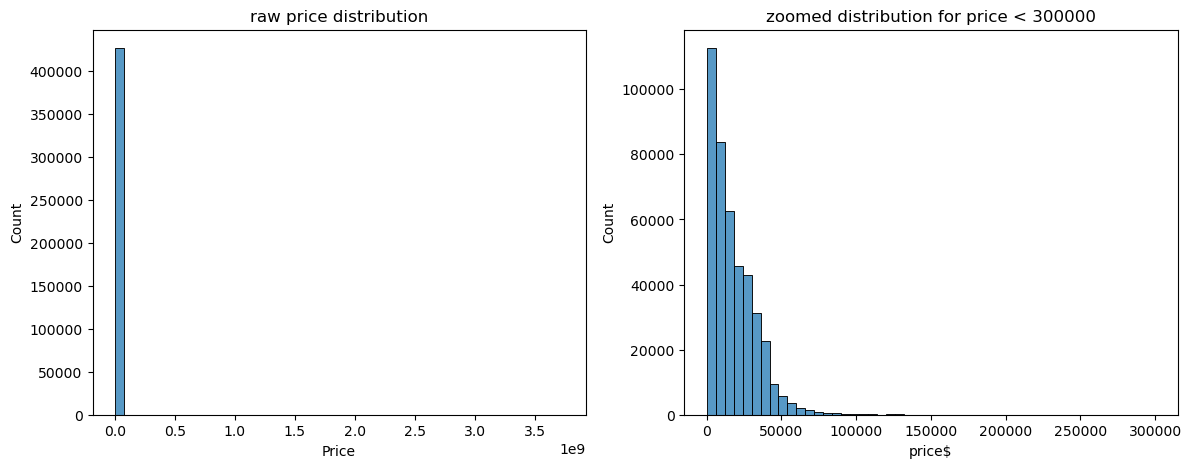

In [195]:

fig,axes = plt.subplots(1,2, figsize = (14,5))
sns.histplot(data['price'], bins = 50, ax = axes[0])
axes[0].set_title ("raw price distribution")
axes[0].set_xlabel ("Price")
sns.histplot(data[data['price']<300000]['price'], bins = 50, ax = axes[1])
axes[1].set_title("zoomed distribution for price < 300000")
axes[1].set_xlabel("price$")
             

In [198]:
len(data[(data['price']>200000) & (data['price'] <300000)])

47

In [205]:
len(data[data['price']>200000])

124

In [206]:
len(data[data['price'] == 0])

32895

In [211]:
len(data[data['price'] < 1000])

46315

In [210]:
data[data['price'] > 500]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy


Text(0.5, 0, 'price$')

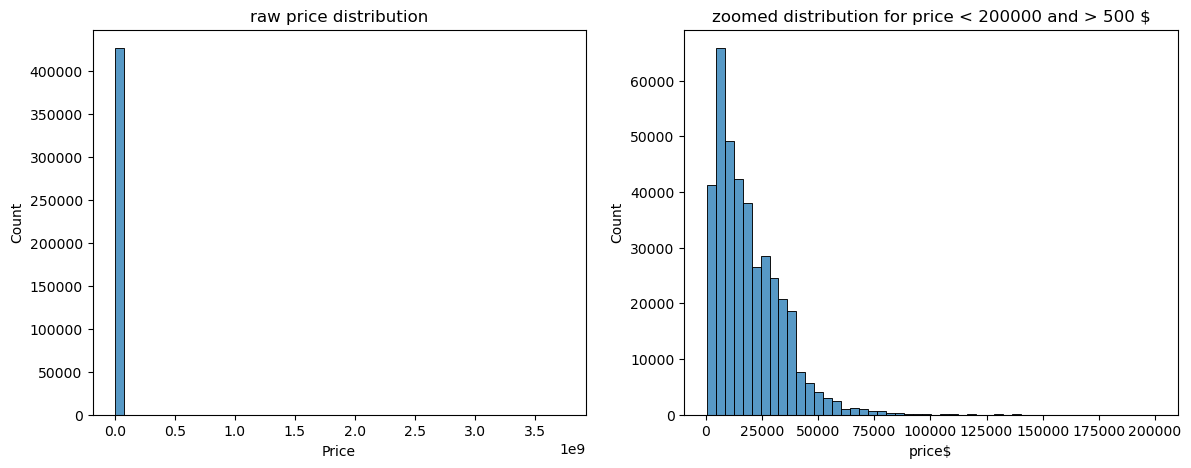

In [209]:
fig,axes = plt.subplots(1,2, figsize = (14,5))
sns.histplot(data['price'], bins = 50, ax = axes[0])
axes[0].set_title ("raw price distribution")
axes[0].set_xlabel ("Price")
# Price distribution within the final valid range: $500 - $200,000
valid_price = data[(data['price'] >= 500) & (data['price'] <= 200000)]['price']
sns.histplot(valid_price, bins = 50, ax = axes[1])
axes[1].set_title("zoomed distribution for price < 200000 and > 500 $")
axes[1].set_xlabel("price$")

### Target: Price distribution

-the raw distribution is unreadable - extreme outliers (upto $3.7 billion ) compress all real vehicles in a single bar.This confirms that there are implausible values that must be removed
- Valid range for modeling: **$500 – $200,000**
- The distribution is strongly **right-skewed**: most vehicles fall between $5,000–$25,000,
  with a long thin tail of legitimate luxury/exotic vehicles extending to $200,000.
  This skew explains why raw mean price ($75k) far exceeds the median ($14k).
- **Cleaning actions identified:** remove $0 placeholders (32,895 rows), sub-$500 nominal
  prices, and corrupt values above $200,000 (124 rows, e.g. $3.7 billion).

In [226]:
data['odometer'].describe()

count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64

In [243]:
Q1_od = 3.770400e+04
Q3_od = 1.335425e+05
IQR_od = Q3_od - Q1_od
min_od = Q1_od - 1.5 * IQR_od
max_od = Q3_od + 1.5 * IQR_od

print(min_od)
print(max_od)


-106053.75
277300.25


In [216]:
len(data[data['odometer']>300000])

3032

In [217]:
data[data['odometer']>300000]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
455,7314165149,birmingham,22500,1929.0,ford,NaN,NaN,NaN,gas,9999999.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,al
527,7313736542,birmingham,5500,2001.0,ford,e350 van,fair,NaN,diesel,340000.0,clean,automatic,NaN,fwd,NaN,van,white,al
562,7313478091,birmingham,27990,2014.0,ram,2500 4x4,like new,6 cylinders,diesel,2222222.0,clean,automatic,NaN,4wd,full-size,truck,white,al
615,7312878239,birmingham,0,2014.0,ram,2500 slt 4x4,like new,6 cylinders,diesel,1111111.0,clean,automatic,NaN,4wd,full-size,truck,white,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426306,7316451826,wyoming,4999,1999.0,ford,f350 crew cab,good,10 cylinders,gas,375400.0,clean,automatic,NaN,4wd,NaN,NaN,black,wy
426377,7313784096,wyoming,8600,2005.0,ford,f350,good,8 cylinders,diesel,305000.0,clean,automatic,NaN,4wd,full-size,truck,blue,wy
426449,7312145049,wyoming,5500,2013.0,ford,expedition el,NaN,NaN,gas,383000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,wy
426505,7311015199,wyoming,8995,2016.0,ford,expedition el,NaN,6 cylinders,gas,388000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,wy


Text(0.5, 0, 'odometer miles')

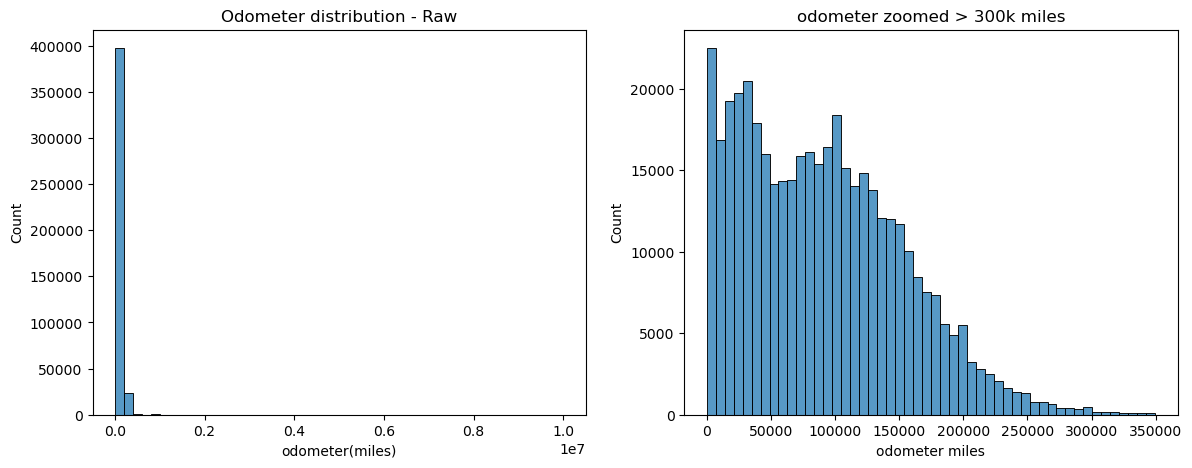

In [224]:
fig, axes = plt.subplots(1,2, figsize = (14,5))
sns.histplot(data['odometer'], bins = 50, ax = axes[0])
axes[0].set_title('Odometer distribution - Raw')
axes[0].set_xlabel('odometer(miles)')

sns.histplot(data[data['odometer']<350000]['odometer'], bins = 50, ax = axes[1])
axes[1].set_title("odometer zoomed > 300k miles")
axes[1].set_xlabel("odometer miles")


Capped odometer at 350,000 miles. Statistical outlier rules (99th percentile 280,000; IQR fence 277,300) suggest a lower threshold, but inspection showed vehicles between 300k–350k are legitimate high-mileage cars (e.g., a 1994 Honda at 300k miles / $750), not data errors. The 350,000 cap removes clearly impossible values (up to 10 million miles) while retaining 99.5% of records, including genuine high-mileage inventory."

In [244]:
temp_data = data[(data['price']>=500)&(data['price']<200000)&(data['odometer']<300000)]

In [ ]:
# Now exploring the year column

In [245]:
temp_data['year'].describe()

count    378508.000000
mean       2011.047088
std           9.511699
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

In [248]:
temp_data.groupby('year')['price'].mean().sort_index()

year
1900.0    14582.666667
1901.0     2499.500000
1905.0     3990.000000
1910.0    15000.000000
1913.0    85000.000000
              ...     
2018.0    30293.727543
2019.0    33982.283762
2020.0    37782.890493
2021.0    40130.101653
2022.0    13176.543478
Name: price, Length: 111, dtype: float64

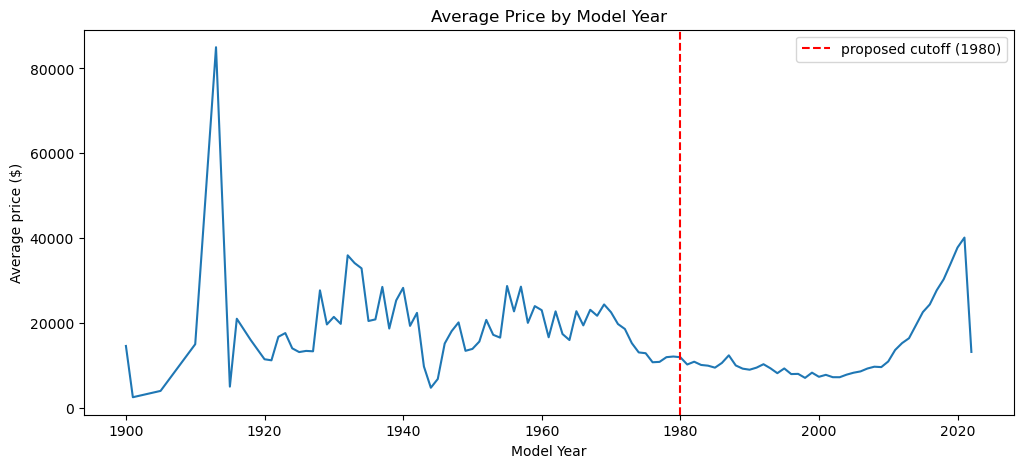

In [249]:
yearly = temp_data.groupby('year')['price'].mean()

plt.figure(figsize=(12,5))
sns.lineplot(x=yearly.index, y=yearly.values)
plt.title('Average Price by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average price ($)')
plt.axvline(1980, color='red', linestyle='--', label='proposed cutoff (1980)')
plt.legend()
plt.show()

"Average price by model year reveals two distinct regimes. Before ~1980, prices are high and volatile with no consistent age relationship — characteristic of the collector/classic market, where value is driven by rarity and restoration rather than age or mileage. From 1980 onward, prices follow a smooth, interpretable pattern: gradual depreciation reaching a floor around 2000, then rising for newer vehicles. Since a linear model assumes a single consistent relationship and the client sells mainstream used cars, vehicles are restricted to model year ≥ 1980."

Text(0.5, 0, 'Model Year')

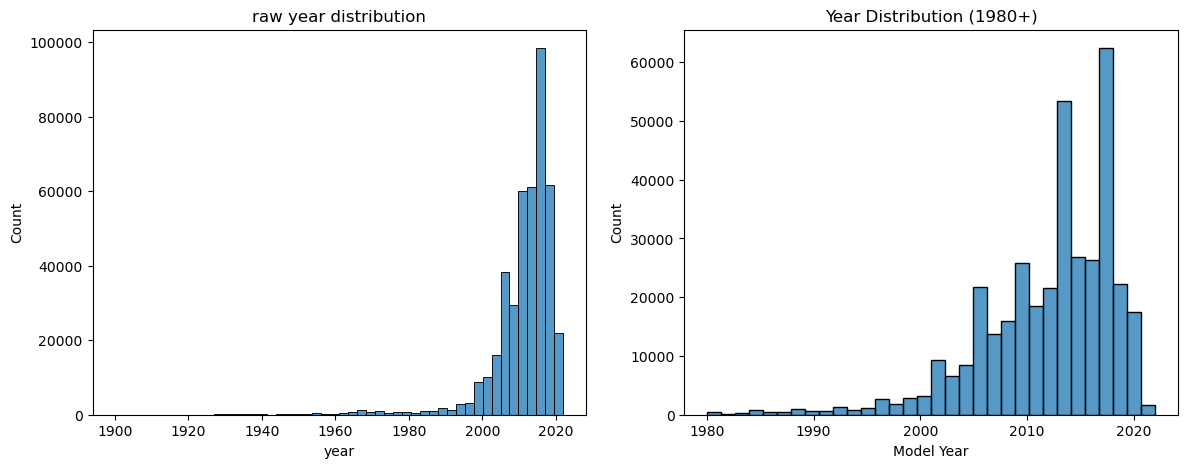

In [251]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(data['year'], bins = 50, ax = axes[0])
axes[0].set_title("raw year distribution")

# zoom to modern era to see the real shape
sns.histplot(temp_data[temp_data['year'] >= 1980]['year'], bins=32, ax=axes[1])
axes[1].set_title('Year Distribution (1980+)')
axes[1].set_xlabel('Model Year')

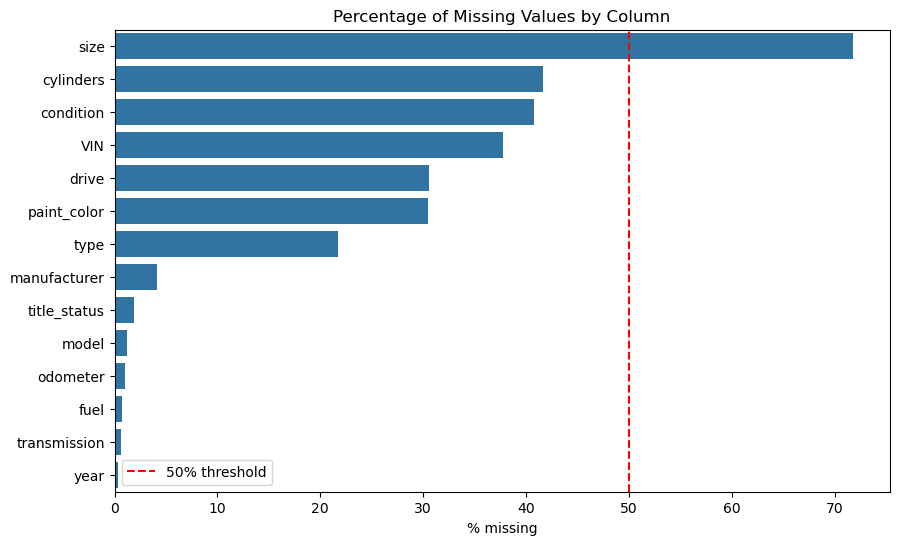

size            71.8
cylinders       41.6
condition       40.8
VIN             37.7
drive           30.6
paint_color     30.5
type            21.8
manufacturer     4.1
title_status     1.9
model            1.2
odometer         1.0
fuel             0.7
transmission     0.6
year             0.3
dtype: float64


In [269]:
missing_pct = (data.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]   # only columns that have gaps

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.title('Percentage of Missing Values by Column')
plt.xlabel('% missing')
plt.ylabel('')
plt.axvline(50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.show()

print(missing_pct.round(1))

1. Drop size , since its missing 71% of values
2. Explore the other features that have 30-50% missing values.Fill them appropriately as needed

In [256]:
print(data.duplicated().sum())

0


Looks like there are no duplicates

In [255]:
#explore object data types and check how many unique values are there - cardinality check

data.select_dtypes(include = 'object').nunique().sort_values(ascending = False)

VIN             118246
model            29649
region             404
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
dtype: int64

1. VIN makes sense - > unique identifier
2. model -> High unique values - 29649 models 
3. region         404 unique  → high
4. state           51 unique  → manageable
5. manufacturer    42 unique  → fine
6. type/color/cylinders/etc  ≤13 → fine

We have to drop model. region needs further investigation

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

Based in the above analysis , drop size, VIN, model, id, region, odometer > 300000 miles, price less than 500 and greater than 100000

In [8]:
data_clean = data.copy()

In [9]:
# 1. Drop columns (identifiers, cardinality explosion, mostly-missing, redundant)
data_clean = data_clean.drop(columns = ['size', 'VIN', 'model', 'id', 'region'])

In [10]:
# 2. Filter rows to plausible / relevant ranges
data_clean = data_clean[data_clean['odometer']<=300000]
data_clean = data_clean[(data_clean['price']>=500) & (data_clean['price']<=250000)]
data_clean = data_clean[data_clean['year']>=1980]

In [11]:
# 3. Engineer age (interpretable), drop year (avoid perfect collinearity)
data_clean['age'] = 2022 - data_clean['year']
data_clean = data_clean.drop(columns = ['year'])

In [12]:
# 4. Fill remaining categorical gaps with "unknown"
cat_cols = data_clean.select_dtypes(include='object').columns
data_clean[cat_cols] = data_clean[cat_cols].fillna('unknown')

In [13]:
#Verify
print("Original shape:", data.shape)
print("Cleaned shape :", data_clean.shape)
print("Rows retained :", f"{len(data_clean)/len(data)*100:.1f}%")
print("Missing cells :", data_clean.isnull().sum().sum())

Original shape: (426880, 18)
Cleaned shape : (371061, 13)
Rows retained : 86.9%
Missing cells : 0


Separate features from target

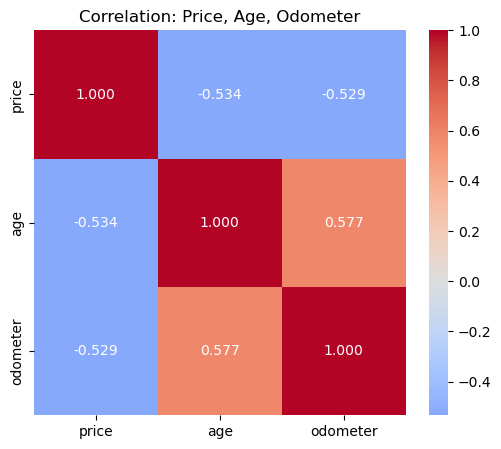

In [18]:
plt.figure(figsize=(6,5))
corr = data_clean[['price','age','odometer']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation: Price, Age, Odometer')
plt.show()

### Inferential Statistics
Beyond the descriptive correlations, I ran statistical tests to confirm these relationships are significant and not due to chance:
- **Pearson correlation** of age and odometer with price are both significant (r ≈ -0.53, p ≈ 0), confirming that older, higher-mileage cars cost less.
- **One-way ANOVA** shows mean price differs very significantly across fuel types (F ≈ 9578, p ≈ 0) and body types (F ≈ 4489, p ≈ 0), confirming these categorical features are genuinely related to price.

In [ ]:
# Inferential statistics: are these relationships statistically significant?
from scipy.stats import pearsonr, f_oneway

# Pearson correlation with p-values (numeric features vs price)
for col in ['age', 'odometer']:
    r, p = pearsonr(data_clean[col], data_clean['price'])
    print(f'Pearson {col} vs price: r={r:.3f}, p={p:.2e}')

# ANOVA: does mean price differ across categories?
F, p = f_oneway(*[g['price'].values for _, g in data_clean.groupby('fuel')])
print(f'ANOVA price ~ fuel type: F={F:.1f}, p={p:.2e}')
F, p = f_oneway(*[g['price'].values for _, g in data_clean.groupby('type')])
print(f'ANOVA price ~ body type: F={F:.1f}, p={p:.2e}')

Pearson age vs price: r=-0.534, p=0.00e+00
Pearson odometer vs price: r=-0.529, p=0.00e+00
ANOVA price ~ fuel type: F=9577.5, p=0.00e+00
ANOVA price ~ body type: F=4489.2, p=0.00e+00

### Correlation (numeric features)
- Both age (−0.53) and odometer (−0.53) show moderate negative correlation with price.
- age ↔ odometer = 0.58 — moderate but below the 0.7 concern threshold; both features
  retained as each carries independent information.
- Note: Pearson correlation measures only linear association; the scatterplots reveal
  stronger curved relationships, so these values understate the true dependence.

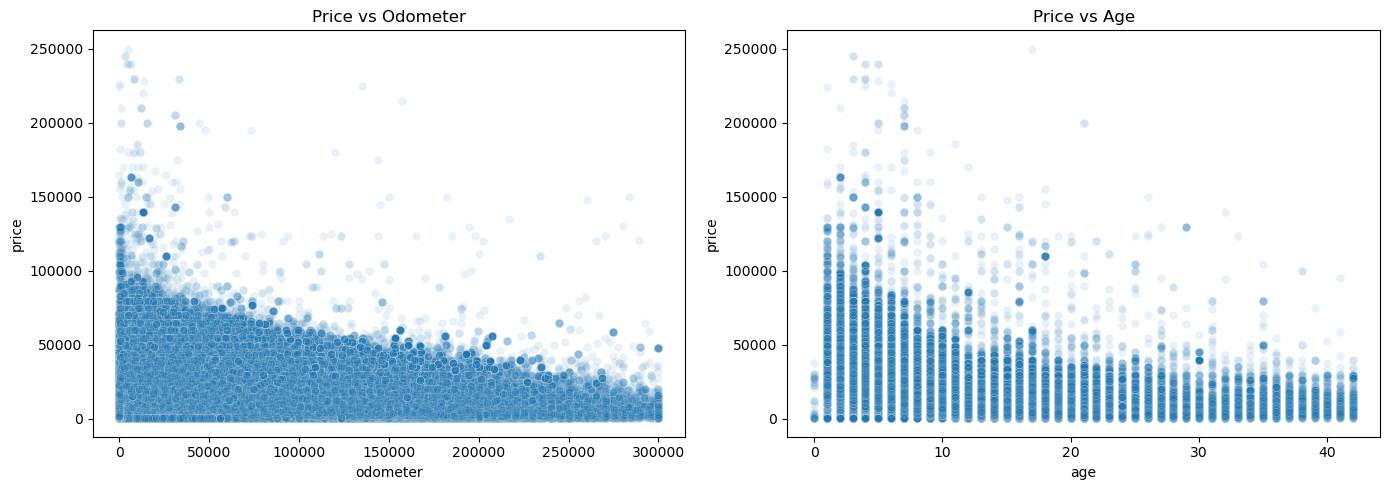

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=data_clean, x='odometer', y='price', alpha=0.1, ax=axes[0])
axes[0].set_title('Price vs Odometer')

sns.scatterplot(data=data_clean, x='age', y='price', alpha=0.1, ax=axes[1])
axes[1].set_title('Price vs Age')

plt.tight_layout()
plt.show()

### Relationships: numeric features vs price
- Price declines with both odometer and age, confirming the two strongest expected drivers.
- **Both relationships are nonlinear**: price falls steeply early (first ~50k miles /
  first few years) then flattens — characteristic curved depreciation.
- This foreshadows a limitation: a linear model fits a straight line to these curved
  relationships, which will cause underfitting. Polynomial or tree-based models would
  capture the curvature better (noted for future work).

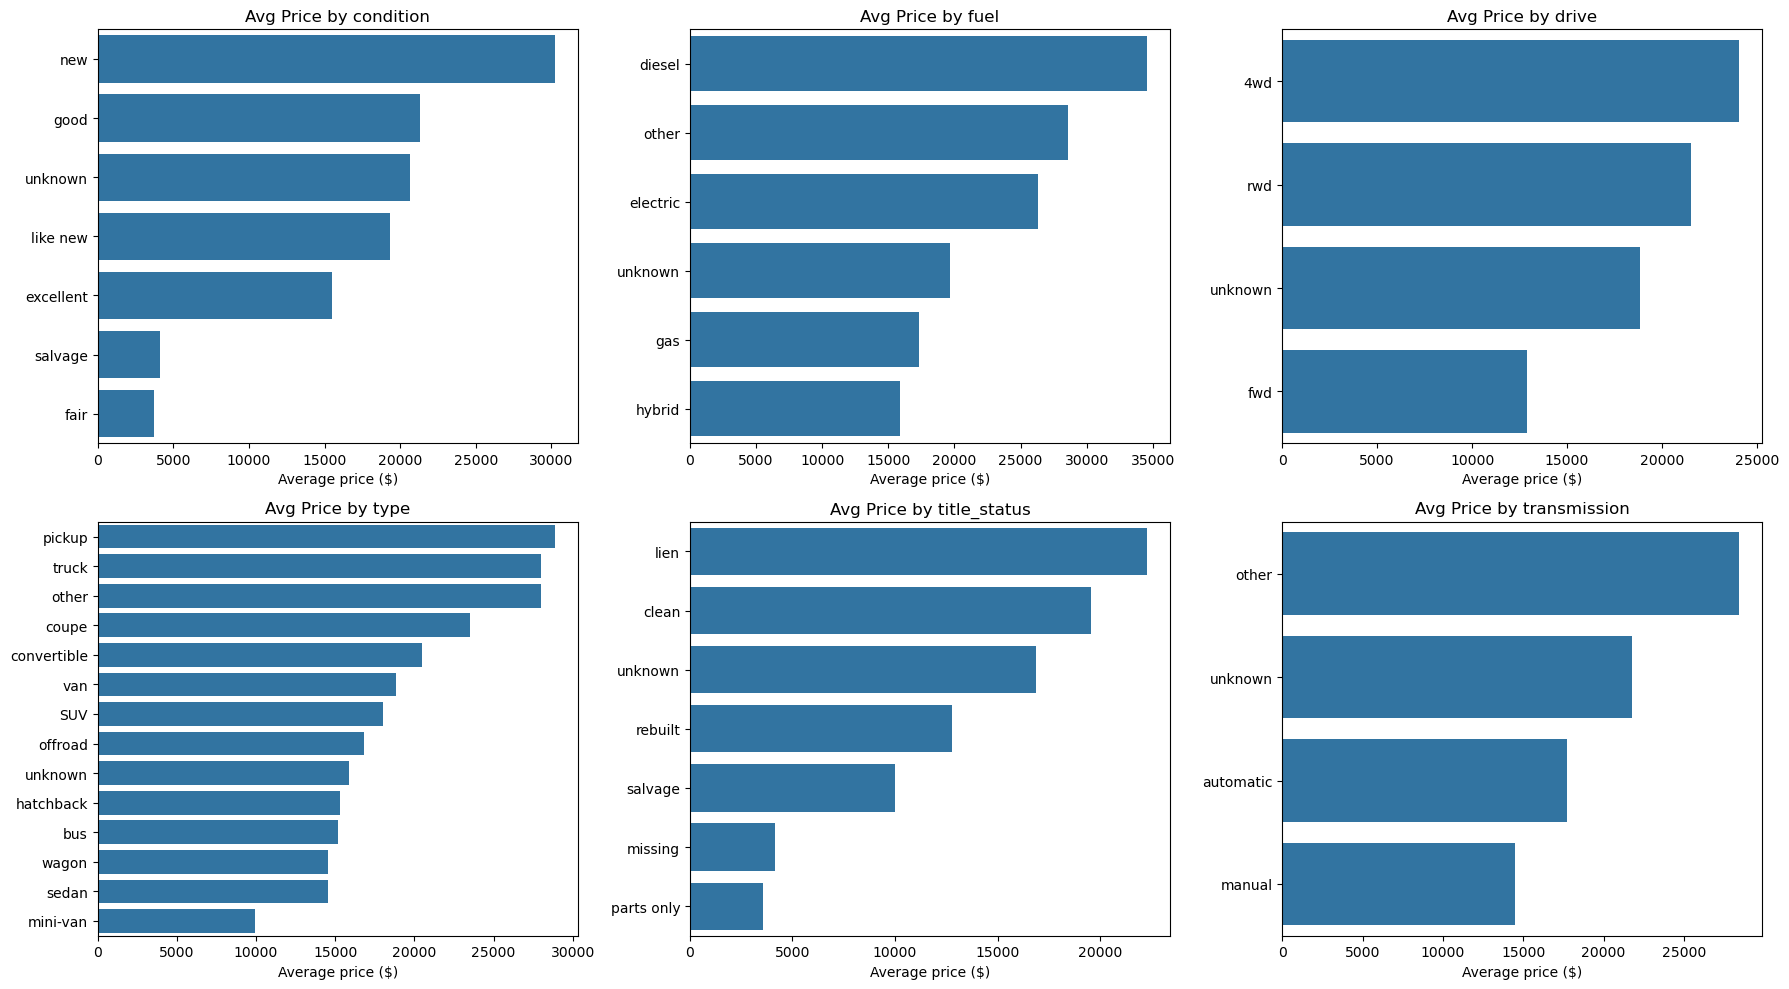

In [19]:
cat_features = ['condition', 'fuel', 'drive', 'type', 'title_status', 'transmission']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    means = data_clean.groupby(col)['price'].mean().sort_values(ascending=False)
    sns.barplot(x=means.values, y=means.index, ax=axes[i])
    axes[i].set_title(f'Avg Price by {col}')
    axes[i].set_xlabel('Average price ($)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Relationships: categorical features vs price
- **Vehicle type is a major driver:** pickups/trucks (~$28k) far exceed sedans/minivans
  (~$10-15k). Reinforced by fuel (diesel $34k) and drive (4wd $24k) — all reflecting a
  truck/utility premium. Note these three features are partly confounded (diesel and 4wd
  are concentrated in trucks).
- **Title status matters:** clean titles (~$20k) are worth ~5x parts-only titles (~$4k).
- **Condition** trends sensibly (new $30k → salvage $4k), though "good" > "excellent"
  suggests inconsistent seller labeling.
- Counterintuitive results (hybrids cheaper than gas; transmission "other" highest) reflect
  confounding — e.g., hybrids skew toward economy cars — not causal effects of the feature
  itself. The regression will estimate each effect holding others constant.

In [21]:
X = data_clean.drop(columns = ['price'])

In [22]:
y = data_clean['price']

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (371061, 12)
y shape: (371061,)


In [268]:
cat_cols = X.select_dtypes(include='object').columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [80]:
X_encoded.shape


(364758, 150)

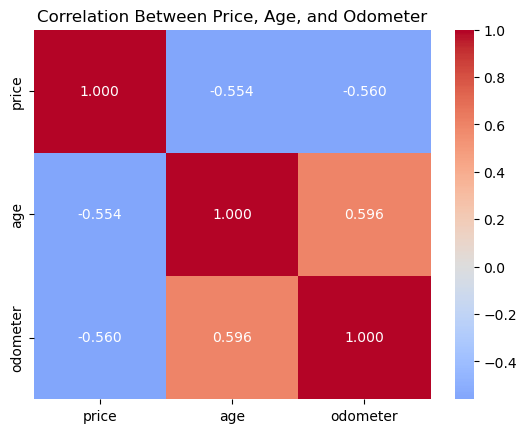

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap of numeric features
corr = data_clean[['price','age','odometer']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Between Price, Age, and Odometer')
plt.show()

/var/folders/rn/391hzp9x6_g39nh101c1yr3w0000gn/T/ipykernel_24231/2187901409.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=means.values, y=means.index, ax=axes[i], palette='viridis')
/var/folders/rn/391hzp9x6_g39nh101c1yr3w0000gn/T/ipykernel_24231/2187901409.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=means.values, y=means.index, ax=axes[i], palette='viridis')
/var/folders/rn/391hzp9x6_g39nh101c1yr3w0000gn/T/ipykernel_24231/2187901409.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=means.values, y=means.index, ax=ax

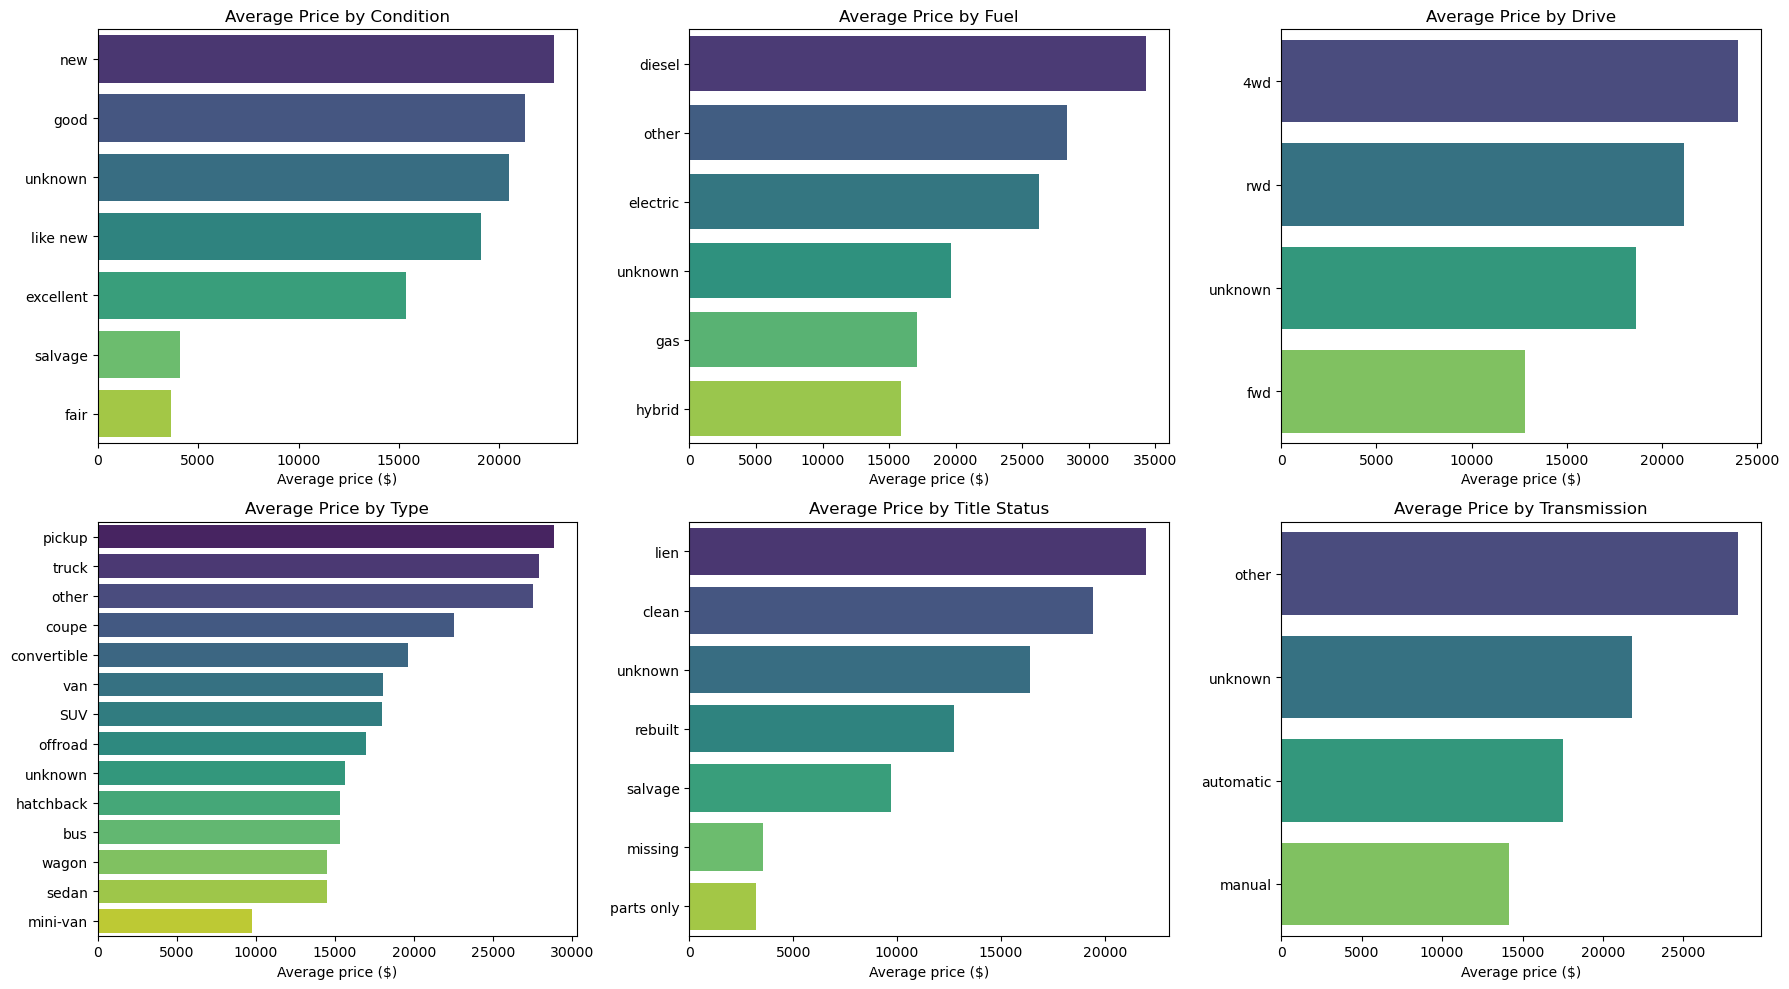

In [85]:
cat_features = ['condition', 'fuel', 'drive', 'type', 'title_status', 'transmission']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))   # grid: 2 rows × 3 columns
axes = axes.flatten()                               # makes the grid easy to loop over

for i, col in enumerate(cat_features):
    # average price for each category, sorted highest to lowest
    means = data_clean.groupby(col)['price'].mean().sort_values(ascending=False)
    
    sns.barplot(x=means.values, y=means.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Average Price by {col.replace("_", " ").title()}')
    axes[i].set_xlabel('Average price ($)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

"Relationship analysis confirmed all retained features show meaningful association with price (correlations for numeric features; group-mean differences for categoricals). No severe multicollinearity was detected (all pairwise |r| < 0.7), so no additional features were removed. Note that some associations are likely confounded — e.g., paint color correlates with price primarily because white is standard for higher-value work vehicles, not because color itself drives value."

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (291806, 150)
Test : (72952, 150)


In [29]:
cat_cols = X.select_dtypes(include='object').columns
X_encoded = pd.get_dummies(X, columns = cat_cols, drop_first = True)

print("Before encoding:", X.shape)
print("After encoding :", X_encoded.shape)

Before encoding: (371061, 12)
After encoding : (371061, 150)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (296848, 150)
Test : (74213, 150)


In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Model trained.")
print("Intercept:", round(lr.intercept_))
print("Number of coefficients:", len(lr.coef_))

Model trained.
Intercept: 63844
Number of coefficients: 150


In [35]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R²  : {r2:.4f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE : ${mae:,.0f}")

               

R²  : 0.6381
RMSE: $8,980
MAE : $5,799


In [36]:
print(f"Train R²: {lr.score(X_train, y_train):.4f}")
print(f"Test  R²: {lr.score(X_test, y_test):.4f}")

Train R²: 0.6384
Test  R²: 0.6381


### Model diagnosis: underfitting
- Train R² (0.638) ≈ Test R² (0.638) — the near-zero gap shows the model generalizes
  well and is NOT overfitting.
- However, both scores plateau around 0.64, indicating **underfitting**: the linear
  model is too simple to capture the curved (nonlinear) relationships observed in the
  price-vs-age and price-vs-odometer scatterplots.
- This is a high-bias situation. Nonlinear models (polynomial regression, decision trees,
  random forests) would likely capture the curvature and improve performance.

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

# scale features (required for penalized models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from TRAIN
X_test_scaled  = scaler.transform(X_test)         # apply SAME mean/std to test

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

# Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

# compare all three
for name, pred in [("Linear", y_pred), ("Ridge", ridge_pred), ("Lasso", lasso_pred)]:
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name:8} R²: {r2:.4f}   RMSE: ${rmse:,.0f}")

print(f"\nLasso zeroed out {(lasso.coef_ == 0).sum()} of {len(lasso.coef_)} features")

Linear   R²: 0.6381   RMSE: $8,980
Ridge    R²: 0.6381   RMSE: $8,980
Lasso    R²: 0.6381   RMSE: $8,980

Lasso zeroed out 0 of 150 features


Regularization: Ridge & Lasso
Ridge and Lasso produced results identical to plain Linear Regression (R² = 0.638 for all), and Lasso eliminated zero features.
This is expected: with 297,000 training rows against 150 features (2,000 rows per feature), the model cannot overfit, so there is no variance for regularization to reduce.
Regularization addresses overfitting (high variance); our model underfits (high bias), so it correctly provides no benefit here. Regularization is most valuable when features are numerous relative to observations — not the case in this dataset.

In [39]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv = 5, scoring = 'r2')
print("5 fold scores:", [round(s, 4) for s in cv_scores])
print(f"Mean CV R²: {cv_scores.mean():.4f}")
print(f"Std of scores: {cv_scores.std():.4f}")

5 fold scores: [np.float64(0.6413), np.float64(0.6381), np.float64(0.6366), np.float64(0.6341), np.float64(0.6382)]
Mean CV R²: 0.6376
Std of scores: 0.0023


### Cross-validation
- 5-fold cross-validation gives a mean R² of 0.638 with a standard deviation of just 0.002.
- The near-identical scores across folds confirm the model is stable and the result is
  reliable — not an artifact of any single train/test split.
- The large dataset (~297k rows) means every fold is representative, so variance across
  folds is minimal.

In [ ]:
# Leakage-safe hyperparameter tuning: scaling is inside a Pipeline, so within each CV fold
# the scaler is fit ONLY on that fold's training data (never on the validation fold).
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
param_grid = {'ridge__alpha': [0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=1)
grid.fit(X_train, y_train)   # unscaled X_train; the pipeline scales inside each fold

print('Best alpha:', grid.best_params_['ridge__alpha'])
print(f'Best CV R2: {grid.best_score_:.4f}')
tuned_pred = grid.predict(X_test)
print(f'Tuned Ridge test R2: {r2_score(y_test, tuned_pred):.4f}')

Best alpha: 1
Best CV R2: 0.6376
Tuned Ridge test R2: 0.6381

The tuned Ridge model (best alpha = 1) gives essentially the same R² (0.638) as the plain linear regression, using a **leakage-safe pipeline** where scaling is fit only on each fold's training data. This confirms the earlier result is not an artifact of preprocessing leakage, and that regularization does not help here — consistent with the model underfitting rather than overfitting.

### Grid search (hyperparameter tuning)
- Grid search over alpha ∈ [0.01, 0.1, 1, 10, 100, 1000], scored by 5-fold cross-validation,
  selected alpha = 10.
- The tuned model (R² = 0.638) performs identically to the untuned baseline, confirming
  that regularization strength does not affect this problem — consistent with the
  underfitting diagnosis. The search was still necessary to establish this empirically
  rather than assume it.

In [41]:
# Build a table of feature → coefficient (from the plain linear model)
coefs = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)

print("=== TOP 15 features that INCREASE price ===")
print(coefs.head(15).to_string(index=False))

print("\n=== TOP 15 features that DECREASE price ===")
print(coefs.tail(15).to_string(index=False))

print("\n=== The two numeric features ===")
print(coefs[coefs['feature'].isin(['age', 'odometer'])].to_string(index=False))

=== TOP 15 features that INCREASE price ===
                  feature  coefficient
     manufacturer_ferrari 83280.748068
manufacturer_aston-martin 22986.878615
      manufacturer_datsun 20065.840000
   cylinders_12 cylinders 15481.898936
       manufacturer_tesla 15100.523492
     manufacturer_porsche 12766.091816
            condition_new  5871.188858
       manufacturer_rover  4497.149971
         type_convertible  4473.309032
             type_offroad  4385.862369
              type_pickup  4261.811987
               type_other  4228.444743
               type_coupe  4202.013125
               type_truck  3911.448486
      transmission_manual  2684.305353

=== TOP 15 features that DECREASE price ===
                     feature   coefficient
     manufacturer_mitsubishi  -8153.048452
manufacturer_harley-davidson -10159.936966
       cylinders_6 cylinders -10370.085840
           manufacturer_fiat -10439.678759
           cylinders_unknown -10632.470936
                  fuel_other 

### Coefficient interpretation (what drives price)
Coefficients are relative to baselines (manufacturer: Acura; fuel: diesel; type: SUV;
condition: excellent; cylinders: 10).

**Strongest drivers:**
- Each year of age: −$852; each 10,000 miles: −$797 (the two most reliable levers)
- Brand: Ferrari (+$83k), Aston Martin (+$23k), Tesla (+$15k) command large premiums over Acura
- Body type: trucks, pickups, convertibles sell ~$4,000 more than SUVs
- Fuel: gas/hybrid/electric all sell $15-18k LESS THAN DIESEL — diesel (heavy-duty trucks)
  is the premium segment
- Larger engines (more cylinders) command higher prices

**Caveats:**
- manufacturer_tesla (+$15k) and fuel_electric (−$18k) are confounded — all Teslas are
  electric, so the model cannot separate these effects; neither coefficient is reliable alone.
- Rare-brand coefficients (Ferrari, Datsun) rest on small samples and are unstable.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

## Evaluation

**Model comparison:** Linear Regression, Ridge, and Lasso were compared, each evaluated
with 5-fold cross-validation and Ridge tuned via grid search over alpha.

| Model | Test R² | RMSE | MAE |
|-------|---------|------|-----|
| Linear Regression | 0.638 | $8,980 | $5,799 |
| Ridge (alpha=10, tuned) | 0.638 | $8,980 | — |
| Lasso | 0.638 | $8,980 | — |

**Chosen metric and rationale:** The primary metric is **R²** (proportion of price variance
explained), supported by **MAE** as the most interpretable error measure ($5,799 average
error in dollars) and **RMSE** ($8,980). RMSE exceeding MAE indicates a subset of large
prediction errors — concentrated in high-value vehicles — which the squared metric penalizes
more heavily.

**Model quality:** All three models perform identically (R² = 0.638). Regularization provided
no benefit because, with ~297,000 training rows against 150 features, the model cannot overfit.
Training R² (0.638) and test R² (0.638) are nearly identical, confirming the model generalizes
well but **underfits** — it is too simple to capture the nonlinear (curved) relationships
between price and both age and odometer that were visible in the scatterplots. This is a
high-bias limitation of linear regression, not a data problem.

**Cross-validation** gave a stable mean R² of 0.638 (± 0.002 across folds), confirming the
result is reliable rather than an artifact of a single train/test split.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Deployment — Findings & Recommendations for the Dealership

**What drives used-car prices (key findings):**

1. **Age and mileage are the two most reliable price drivers.** Each year of age reduces
   value by ~$850, and each 10,000 miles by ~$800, holding all else constant.

2. **Trucks and utility vehicles hold value best.** Pickups, trucks, and off-road vehicles
   sell ~$4,000 more than SUVs; diesel vehicles (mostly heavy-duty trucks) command the
   largest fuel premium.

3. **Title status is a major, controllable factor.** Clean titles are worth far more than
   salvage or parts-only titles.

4. **Brand matters enormously at the extremes.** Luxury/exotic brands (Ferrari, Porsche,
   Tesla) carry large premiums; budget brands (Fiat, Mitsubishi) sell below average.

5. **Condition and engine size** track price as expected (newer/larger = more).

**Recommendations:**
- Prioritize trucks, pickups, and diesel/4WD vehicles — they retain value best.
- Treat clean titles as essential when acquiring inventory.
- Use ~$850/year and ~$800 per 10,000 miles as baseline depreciation when valuing trade-ins.

**Limitations (in plain terms):**
- The model's typical error is ~$5,800, so it is a guide for inventory strategy, not a tool
  for pricing individual vehicles precisely.
- It explains ~64% of price variation; the rest depends on factors not in the data (accident
  history, service records, specific trim, local demand).
- Some patterns are correlations, not causes (e.g., white cars appear pricier because white
  is common on high-value work trucks — repainting a car will not raise its value).

**Next steps:**
- Try nonlinear models (polynomial features, random forests, gradient boosting) to capture
  the curved depreciation the linear model cannot.
- Reintroduce vehicle model (selectively) to capture trim-level price differences.
- Enrich the data with accident and service history.